# Import libraries

In [34]:
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
import emcee
import corner

# Define constants

In [35]:
c = 299792458 * 10**(-3)
H0 = 75
f0 = 6.61* 10**-9 * 10**(-7) * (3.2408*10**(-25))**(-2)

# Some key functions

In [36]:
#order of variables: z, k, omega_M, omega_DE, LPeakLambda, rc

def scale_factor(z):
    return 1/(1+z)

def Friedmann_eq(z, omega_DE):
    a = scale_factor(z)
    omega_M = 1 - omega_DE
    H2 = (H0**2)*(omega_M/(a**3) + omega_DE)
    return np.sqrt(H2)

def integrand(z, omega_DE):
    return c/Friedmann_eq(z, omega_DE)

def co_moving_dist(z, omega_DE):
    z_up = np.concatenate(([0], z))
    r_cm = scp.integrate.odeint(lambda y, t: integrand(t, omega_DE), 0, z_up)
    r_c = np.delete(r_cm, 0)
    return np.ndarray.flatten(r_c)

def mag_model(z, omega_DE, LPeakLambda):
    rc = co_moving_dist(z, omega_DE)
    flux = (1e32)*LPeakLambda/(4*np.pi*((rc*(1+z))**2))
    argument = flux/f0
    mag = -2.5*np.log10(argument)
    return mag

In [37]:
#alt_rc([0,1,2,5,8], 0.7)
"""array([[0.        ],
       [0.77142711],
       [1.20947123],
       [1.8155091 ],
       [2.08819249]])"""

'array([[0.        ],\n       [0.77142711],\n       [1.20947123],\n       [1.8155091 ],\n       [2.08819249]])'

# Load the data

In [38]:
sn_z, sn_mag, sn_mag_err = np.loadtxt("sn_data.txt", usecols=(1,2,3), unpack = True)
sort_IDs = np.argsort(sn_z)
sn_z = sn_z[sort_IDs]
sn_mag = sn_mag[sort_IDs]
sn_mag_err = sn_mag_err[sort_IDs]


"""LCDMf = lambda x: 1.0/np.sqrt(0.3*(1+x)**3+0.7)
myarray = np.array([0,4,5,2,7,3,8,5,1,77,8,35,7,3,775,0.7674,0.57464,1,4.85757])
sortid = np.argsort(myarray)
myarray = myarray[sortid]
myarray
#scp.integrate.odeint(lambda y, t: LCDMf(t), 0, sn_z)
#alt_rc(sn_z, 0.7)
print(f"{len(sn_z)}, {len(alt_rc(sn_z,0.7))}")
print(sn_z)
print(alt_rc(sn_z, 0.99))"""

'LCDMf = lambda x: 1.0/np.sqrt(0.3*(1+x)**3+0.7)\nmyarray = np.array([0,4,5,2,7,3,8,5,1,77,8,35,7,3,775,0.7674,0.57464,1,4.85757])\nsortid = np.argsort(myarray)\nmyarray = myarray[sortid]\nmyarray\n#scp.integrate.odeint(lambda y, t: LCDMf(t), 0, sn_z)\n#alt_rc(sn_z, 0.7)\nprint(f"{len(sn_z)}, {len(alt_rc(sn_z,0.7))}")\nprint(sn_z)\nprint(alt_rc(sn_z, 0.99))'

## Priors

Parameters of model are: {k, H0, omega_M, omega_DE, LPeakLambda}

Priors are: {k=0, H0~70, etc}

Should priors be uniform or Gaussian over the range? - use uniform unless I have good reasons to use a Gaussian (eg if I use the Planck result as a prior, the prior could be a Gaussian with st dev being the error given by Planck)

In [39]:
def log_prior(theta):
    omega_DE, LPeakLambda = theta
    if 0<omega_DE<1 and 0<LPeakLambda<10:
        return 0.0
    return -np.inf

priors_central = [0.5, 5]
    

# Likelihood function

In [40]:
def log_likelihood(theta, z, mag, magerr):
    omega_DE, LPeakLambda = theta
    model = mag_model(z, omega_DE, LPeakLambda)
    return -0.5*np.sum(((mag - model)**2)/(magerr**2))


def log_probability(theta, z, mag, magerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mag, magerr)


# The MCMC algorithm

Questions to investigate: how many chains should I discard? What is burn in? How many walkers do I need? How many steps should the walkers take?

In [53]:
pos = priors_central + 0.5*np.random.rand(5000, 2)
nsteps = 5000 #number of steps walkers take
nwalkers, ndim = pos.shape
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args = (sn_z, sn_mag, sn_mag_err)
)
sampler.run_mcmc(pos, nsteps, progress = True)

100%|██████████| 5000/5000 [1:40:20<00:00,  1.20s/it]  


State([[0.7073625  3.32535904]
 [0.71454993 3.2387272 ]
 [0.75110901 3.1603951 ]
 ...
 [0.82206191 3.35307778]
 [0.73489663 3.24428978]
 [0.72608732 3.35721574]], log_prob=[-52.32237276 -51.64745734 -53.0769351  ... -53.37305324 -51.80332975
 -52.47750863], blobs=None, random_state=('MT19937', array([2126764168,  356862398, 3798033608,  718065514, 1534644053,
        855173899, 1852727265, 1884926236, 1374806461, 1837418933,
       3420249721,   33167073,   92716658, 3642139966, 3137608259,
       3652398173, 4141729748,  811306498, 1460201523,  693830451,
       2207181741,    5228018, 4066437152, 3836801218, 1303001354,
       4017226440, 2095734591, 2863135664,  445590845,  907783633,
       4036346189, 1457444633,  380500019, 2095550328,  621922667,
       4185146838, 1074228362,  562223461, 3597308772, 3860547808,
       3064861918, 2886118290,  459765999, 2909820857,  984970304,
       1748651474, 3481311439, 4195003087,  351777314, 4099334057,
       1403349003, 2546743309, 1554

[30.41555813 31.25763121]


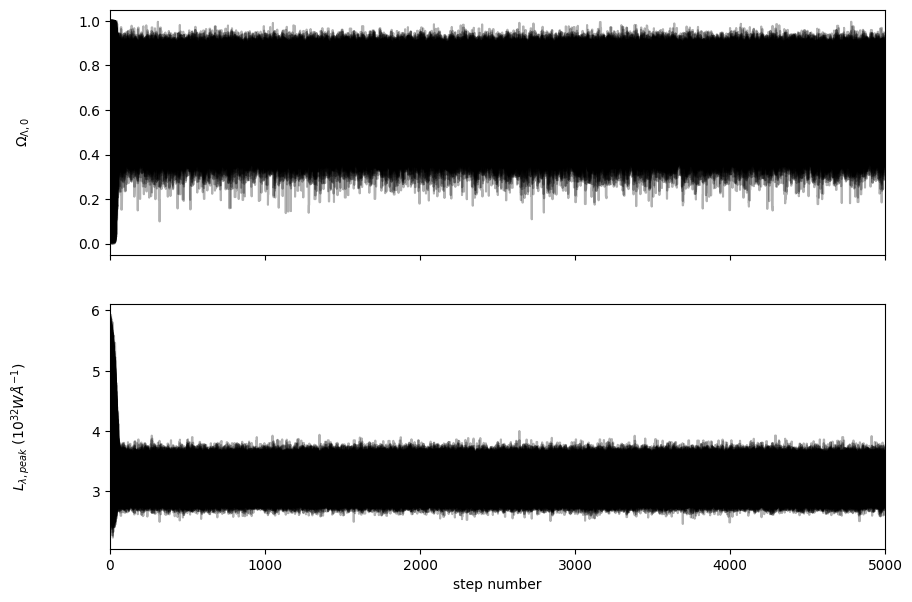

In [54]:
ndiscard = 200  #how many steps at the beginning of the chain to discard
flat_samples = sampler.get_chain(discard = ndiscard, thin = 15, flat = True)

fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["${Ω_{Λ,0}}$", "${L_{λ, peak}}$ ${(10^{32} W Å^{-1})}$"] 
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

print(sampler.get_autocorr_time())

# Covariance plots

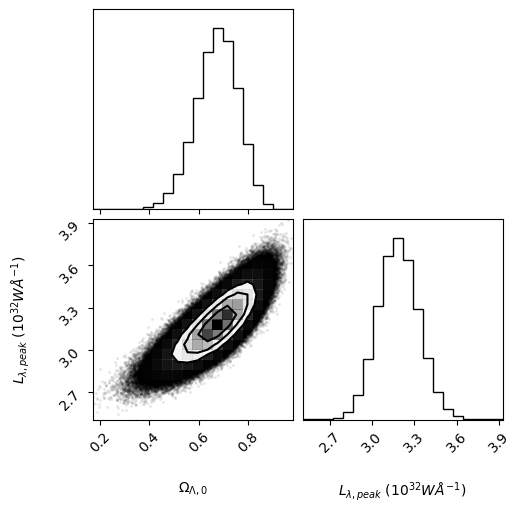

In [55]:

fig = corner.corner(
    flat_samples, labels = labels
)
plt.savefig("corner.png")

In [56]:


for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [34, 50, 68])
    q = np.diff(mcmc)
    print(f"{labels[i]}: {mcmc[1]}, {q[0]}, {q[1]}")

${Ω_{Λ,0}}$: 0.6756397391292986, 0.03609480352177663, 0.03910065568385013
${L_{λ, peak}}$ ${(10^{32} W Å^{-1})}$: 3.181612397503938, 0.05841022029925025, 0.06717164475532122
